## Opdracht: Ontwerp je Eigen Features & Bouw een Simpele Decision Tree

Je gaat zelf ontdekken hoe je informatie uit afbeeldingen kunt halen door:
- **je mag geen externa libraries gebruiken (behalve numpy)**
- Zelf features te bedenken (kenmerken)
- Die features meetbaar te maken met Python
- Een héél simpele decision tree te bouwen die op basis van jouw features probeert een getal te herkennen
- Te onderzoeken waarom bepaalde features wel of niet goed werken

Je hoeft hiervoor nog niets te weten over machine learning of accuracy.
Deze opdracht gaat om begrijpen, onderzoeken, uitleggen, en experimenteren.

Trainset : (60000, 28, 28)  (dtype=uint8)
Testset  : (10000, 28, 28)


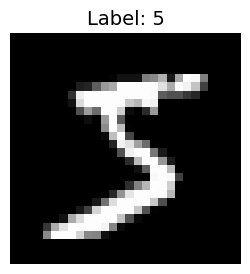

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Trainset : {X_train.shape}  (dtype={X_train.dtype})")
print(f"Testset  : {X_test.shape}")

def toon_afbeelding(img, label=None):
    plt.figure(figsize=(3, 3))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    if label is not None:
        plt.title(f"Label: {label}", fontsize=14)
    plt.show()

toon_afbeelding(X_train[0], label=y_train[0])

### Deel 1 Maak losse methodes per feature



Een feature is één getal dat iets zegt over de afbeelding.
Voorbeelden (je mag kiezen of totaal iets anders verzinnen):

- Hoeveel donkere pixels zitten er in de afbeelding?
- Is de afbeelding links donkerder dan rechts?
- Hoe hoog en hoe breed is de “vorm”?
- Hoe symmetrisch is het cijfer?
- iets met stdev?
- Hoeveel aparte stukjes donkere pixels bevat het?

### Gekozen features en motivering

| # | Feature | Waarom nuttig |
|---|---------|---------------|
| 0 | `procent_donkere_pixels` | Cijfer **1** heeft weinig inkt; **8** juist veel |
| 1 | `horizontale_symmetrie` | **0**, **1** en **8** zouden links-rechts symmetrisch moeten zijn |
| 2 | `verticale_verdeling` | **7** is boven-zwaar; **6** onder-zwaar |
| 3 | `horizontale_verdeling` | **3** is rechts-zwaar; **5** links-zwaar |
| 4 | `bounding_box_ratio` | **1** is smal & lang (ratio > 2); **0** is rond (ratio ~1.2) |
| 5 | `pixel_stdev` | Hoge spreiding = scherpe randpixels; laag = vage vorm |
| 6 | `aantal_gaten` | **0**→1 gat, **8**→2 gaten, **4/6/9**→1 gat, rest→0 gaten |

In [10]:
def procent_donkere_pixels(img):
    """Fractie pixels die tot het cijfer behoren (waarde > 127)."""
    return float(np.sum(img > 127)) / img.size

def horizontale_symmetrie(img):
    links  = img[:, :14].astype(np.float32)
    rechts = np.fliplr(img[:, 14:]).astype(np.float32)
    return float(np.mean(np.abs(links - rechts)) / 255.0)

def verticale_verdeling(img):
    boven  = int(np.sum(img[:14, :] > 127))
    onder  = int(np.sum(img[14:, :] > 127))
    totaal = boven + onder
    return boven / totaal if totaal else 0.5

def horizontale_verdeling(img):
    links  = int(np.sum(img[:, :14] > 127))
    rechts = int(np.sum(img[:, 14:] > 127))
    totaal = links + rechts
    return links / totaal if totaal else 0.5

def bounding_box_ratio(img):
    rijen = np.any(img > 127, axis=1)
    kols  = np.any(img > 127, axis=0)
    if not rijen.any() or not kols.any():
        return 1.0
    return float(rijen.sum()) / float(kols.sum())

def pixel_stdev(img):
    return float(np.std(img.astype(np.float32)) / 255.0)

def aantal_gaten(img):
    binair = (img < 128).astype(np.uint8)
    hoogte, breedte = binair.shape
    gevuld = binair.copy()
    buren  = ((-1, 0), (1, 0), (0, -1), (0, 1))

    stapel = []
    for rij in range(hoogte):
        for kolom in (0, breedte - 1):
            if gevuld[rij, kolom] == 1:
                gevuld[rij, kolom] = 2
                stapel.append((rij, kolom))
    for kolom in range(breedte):
        for rij in (0, hoogte - 1):
            if gevuld[rij, kolom] == 1:
                gevuld[rij, kolom] = 2
                stapel.append((rij, kolom))

    while stapel:
        rij, kolom = stapel.pop()
        for delta_rij, delta_kolom in buren:
            buur_rij, buur_kolom = rij + delta_rij, kolom + delta_kolom
            if 0 <= buur_rij < hoogte and 0 <= buur_kolom < breedte and gevuld[buur_rij, buur_kolom] == 1:
                gevuld[buur_rij, buur_kolom] = 2
                stapel.append((buur_rij, buur_kolom))

    gaten  = (gevuld == 1)
    gezien = np.zeros_like(gaten, dtype=bool)
    teller = 0

    for rij in range(hoogte):
        for kolom in range(breedte):
            if gaten[rij, kolom] and not gezien[rij, kolom]:
                teller += 1
                component_stapel = [(rij, kolom)]
                gezien[rij, kolom] = True
                while component_stapel:
                    huidige_rij, huidige_kolom = component_stapel.pop()
                    for delta_rij, delta_kolom in buren:
                        buur_rij, buur_kolom = huidige_rij + delta_rij, huidige_kolom + delta_kolom
                        if (0 <= buur_rij < hoogte and 0 <= buur_kolom < breedte
                                and gaten[buur_rij, buur_kolom] and not gezien[buur_rij, buur_kolom]):
                            gezien[buur_rij, buur_kolom] = True
                            component_stapel.append((buur_rij, buur_kolom))
    return teller

for cijfer in [0, 1, 4, 6, 8, 9]:
    idx = int(np.where(y_train == cijfer)[0][0])
    g   = aantal_gaten(X_train[idx])
    print(f"Cijfer {cijfer}: {g} gat(en)")

Cijfer 0: 1 gat(en)
Cijfer 1: 0 gat(en)
Cijfer 4: 0 gat(en)
Cijfer 6: 1 gat(en)
Cijfer 8: 2 gat(en)
Cijfer 9: 1 gat(en)


### Deel 2: Combineer je features

Maak een methode die per afbeelding een matrix van deze features aanmaakt. Roep deze functie aan voor een (sub)set aan Mnist afbeeldingen. 

**Antwoord op de vragen:**

1. **Hoeveel afbeeldingen?** We gebruiken **N = 1000** trainingsafbeeldingen.  
   Dit is genoeg om de boom mee te debuggen en te evalueren.  
   De `aantal_gaten`-functie gebruikt een Python-stapel en is ±O(28×28) per beeld; bij 1 000 beelden duurt dat een paar seconden.

2. **Welke datastructuur?**  
   - `feature_matrix` — NumPy array met vorm `(N, 7)`, dtype `float32`.  
   - `labels` — NumPy array met vorm `(N,)`, dtype `uint8`.  
   NumPy arrays zijn geheugenefficiënt en eenvoudig te doorzoeken of te analyseren.

In [11]:
FEATURE_NAMEN = [
    "procent_donker",
    "horiz_symmetrie",
    "vert_verdeling",
    "horiz_verdeling",
    "bbox_ratio",
    "pixel_stdev",
    "aantal_gaten",
]

def extract_features(img):
    return [
        procent_donkere_pixels(img),
        horizontale_symmetrie(img),
        verticale_verdeling(img),
        horizontale_verdeling(img),
        bounding_box_ratio(img),
        pixel_stdev(img),
        float(aantal_gaten(img)),
    ]

N = 1000
print(f"Features berekenen voor {N} trainingsafbeeldingen ...")

feature_matrix = np.zeros((N, len(FEATURE_NAMEN)), dtype=np.float32)
labels         = y_train[:N].copy()

for i in range(N):
    feature_matrix[i] = extract_features(X_train[i])
    if (i + 1) % 200 == 0:
        print(f"  {i + 1}/{N} verwerkt")

print("Klaar!")
print(f"\nVorm feature_matrix : {feature_matrix.shape}")
print(f"Vorm labels         : {labels.shape}")


Features berekenen voor 1000 trainingsafbeeldingen ...
  200/1000 verwerkt
  400/1000 verwerkt
  600/1000 verwerkt
  800/1000 verwerkt
  1000/1000 verwerkt
Klaar!

Vorm feature_matrix : (1000, 7)
Vorm labels         : (1000,)


In [12]:
print(f"{'Cijfer':>6}  ", end="")
for naam in FEATURE_NAMEN:
    print(f"{naam:>16}", end="")
print()

for cijfer in range(10):
    masker = (labels == cijfer)
    if masker.sum() == 0:
        continue
    gemiddelden = feature_matrix[masker].mean(axis=0)
    print(f"  {cijfer:>4}  ", end="")
    for v in gemiddelden:
        print(f"{v:>16.3f}", end="")
    print()

Cijfer    procent_donker horiz_symmetrie  vert_verdeling horiz_verdeling      bbox_ratio     pixel_stdev    aantal_gaten
     0             0.175           0.195           0.480           0.477           1.165           0.345           0.928
     1             0.081           0.111           0.474           0.412           2.640           0.247           0.000
     2             0.151           0.168           0.411           0.447           1.061           0.322           0.525
     3             0.146           0.171           0.493           0.411           1.229           0.318           0.032
     4             0.118           0.128           0.433           0.452           1.261           0.288           0.048
     5             0.125           0.147           0.480           0.467           1.091           0.293           0.022
     6             0.139           0.139           0.398           0.463           1.476           0.310           1.160
     7             0.114        

1) Op hoeveel afbeeldingen heb je extract_features functie toegepast? Waarom heb je voor dit aantal gekozen?

**Antwoord:** Op 1000 afbeeldingen. Dit is genoeg om representatieve gemiddelden per cijfer te berekenen en de boom te testen. Meer zou langer duren vanwege de `aantal_gaten`-functie die per beeld O(28×28) is.

2) Welke datastructuur heb je gebruikt om je nieuwe dataset in op te slaan en waarom?

**Antwoord:** Een NumPy array `feature_matrix` met vorm `(N, 7)` en dtype `float32`, plus een apart `labels` array. NumPy arrays zijn geheugenefficiënt, snel te slicen, en eenvoudig om gemiddelden/statistieken mee te berekenen.

### Deel 3: Decision tree maken

We gebruiken **geen scikit-learn** .
Je bouwt een klein boompje met splitsingen.

De boom gebruikt de volgende logica (van links naar rechts = feature < drempel):

```
[gaten < 1.5?]
 ├─ JA  (0 of 1 gat)
 │   ├─ [gaten < 0.5?]  → 0 gaten
 │   │   ├─ JA
 │   │   │   ├─ [donker < 0.08?]   → weinig inkt → 1
 │   │   │   └─ NEE
 │   │   │       ├─ [bbox > 2.0?]  → smal/lang   → 1
 │   │   │       └─ NEE
 │   │   │           ├─ [vert > 0.58?]            → 7  (boven-zwaar)
 │   │   │           └─ NEE
 │   │   │               ├─ [horiz < 0.46?]       → 3  (rechts-zwaar)
 │   │   │               └─ NEE
 │   │   │                   ├─ [vert < 0.50?]    → 5  (iets onder-zwaar)
 │   │   │                   └─ NEE               → 2
 │   └─ NEE  (1 gat → 0, 4, 6, 9)
 │       ├─ [vert > 0.52?]  → gat boven           → 9
 │       └─ NEE
 │           ├─ [vert < 0.44?]  → gat onder       → 6
 │           └─ NEE
 │               ├─ [bbox > 1.5?]  → smal/lang    → 4
 │               └─ NEE                            → 0
 └─ NEE (2 gaten)                                  → 8
```

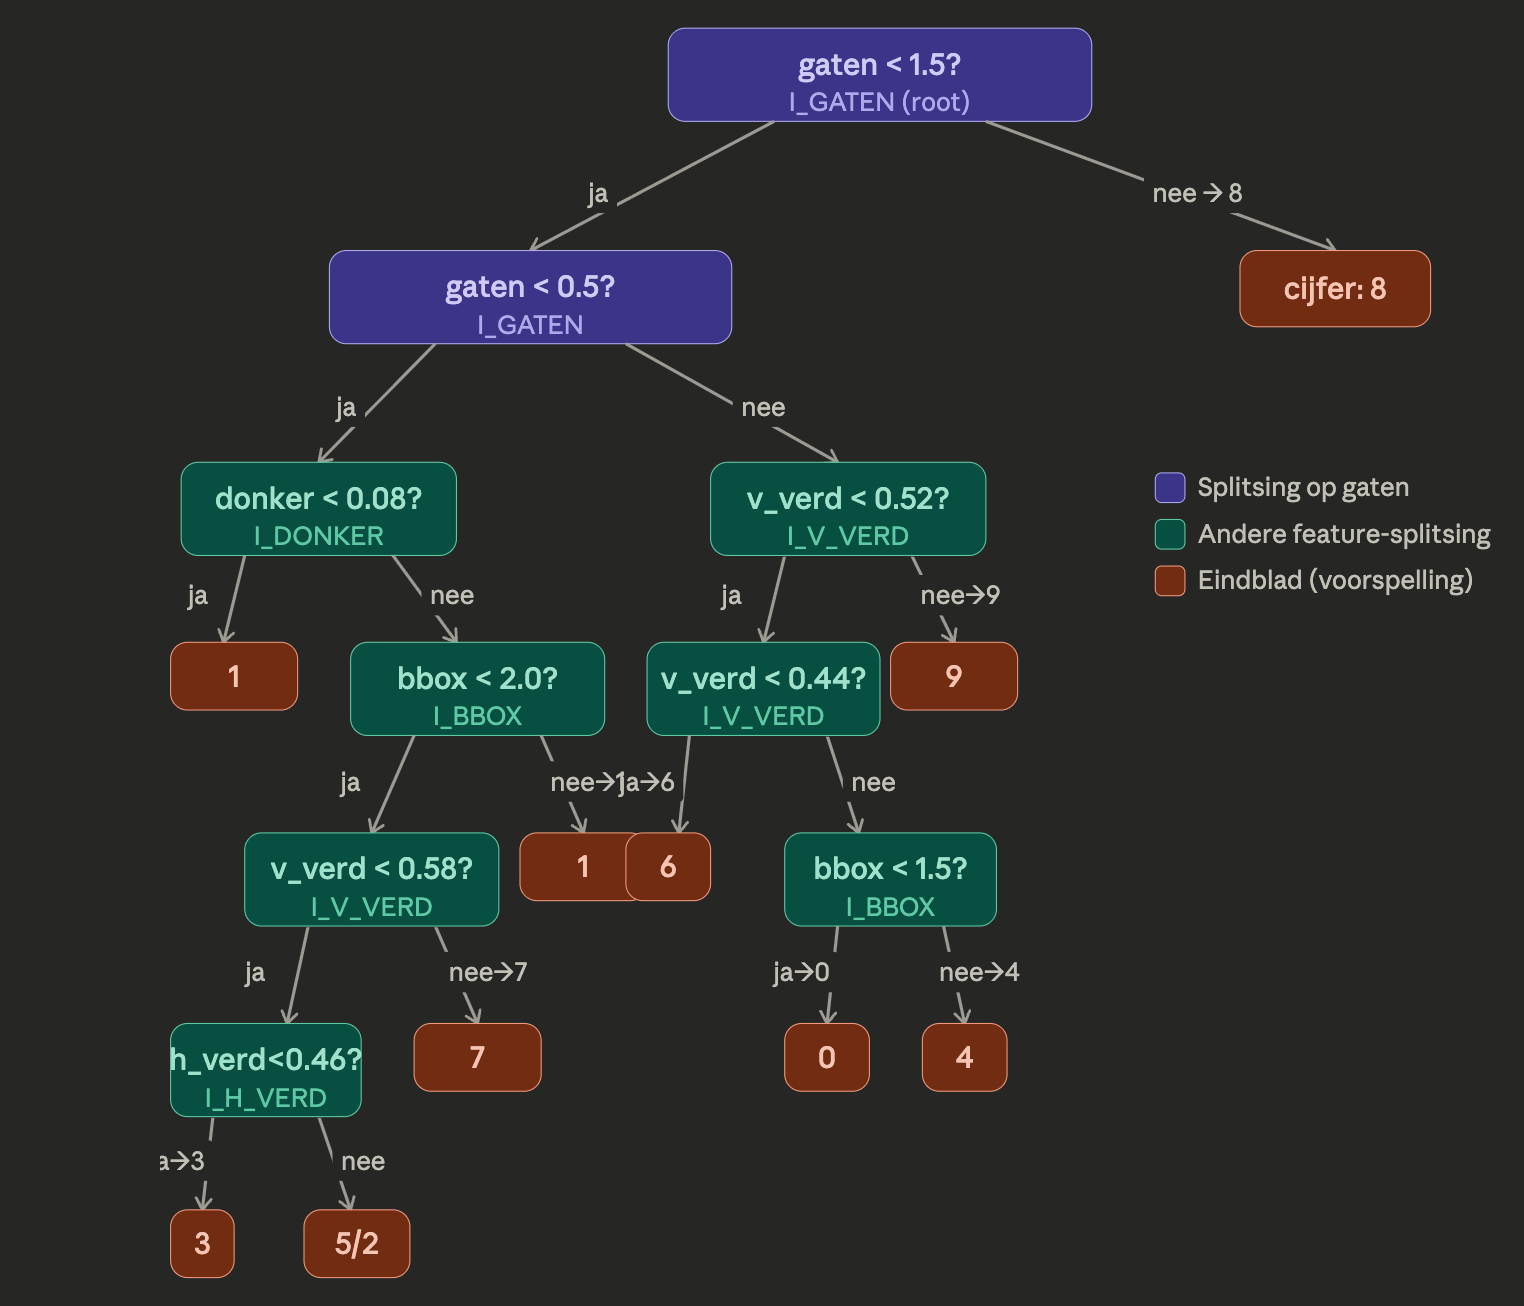

In [13]:
I_DONKER = 0
I_H_SYM  = 1
I_V_VERD = 2
I_H_VERD = 3
I_BBOX   = 4
I_STDEV  = 5
I_GATEN  = 6


class Knoop:
    def __init__(self, feat=None, drempel=None,
                 links=None, rechts=None, label=None):
        self.feat    = feat
        self.drempel = drempel
        self.links   = links
        self.rechts  = rechts
        self.label   = label


def voorspel(knoop, features):
    if knoop.label is not None:
        return knoop.label
    if features[knoop.feat] < knoop.drempel:
        return voorspel(knoop.links,  features)
    else:
        return voorspel(knoop.rechts, features)


boom = Knoop(feat=I_GATEN, drempel=1.5,

    links=Knoop(feat=I_GATEN, drempel=0.5,

        links=Knoop(feat=I_DONKER, drempel=0.08,
            links=Knoop(label=1),
            rechts=Knoop(feat=I_BBOX, drempel=2.0,
                rechts=Knoop(label=1),
                links=Knoop(feat=I_V_VERD, drempel=0.58,
                    rechts=Knoop(label=7),
                    links=Knoop(feat=I_H_VERD, drempel=0.46,
                        links=Knoop(label=3),
                        rechts=Knoop(feat=I_V_VERD, drempel=0.50,
                            links=Knoop(label=5),
                            rechts=Knoop(label=2)
                        )
                    )
                )
            )
        ),

        rechts=Knoop(feat=I_V_VERD, drempel=0.52,
            rechts=Knoop(label=9),
            links=Knoop(feat=I_V_VERD, drempel=0.44,
                links=Knoop(label=6),
                rechts=Knoop(feat=I_BBOX, drempel=1.5,
                    rechts=Knoop(label=4),
                    links=Knoop(label=0)
                )
            )
        )
    ),

    rechts=Knoop(label=8)
)

print("Boom succesvol opgebouwd!")

Boom succesvol opgebouwd!


### Deel 4: Testen

Je laat de boom op een aantal nieuwe afbeeldingen een voorspelling doen.

Bijvoorbeeld:

- toon 10 nieuwe cijfers
- laat de boom voorspellen
- vergelijk met het echte label
- bespreek wat opvalt

In [14]:
N_TEST = 20
print(f"{'Nr':>3}  {'Echt':>5}  {'Voorspeld':>9}  {'OK?':>4}")
print("-" * 30)

correct = 0
for i in range(N_TEST):
    img   = X_test[i]
    feat  = extract_features(img)
    pred  = voorspel(boom, feat)
    echt  = int(y_test[i])
    vlag  = "OK" if pred == echt else "NO"
    print(f"{i:>3}  {echt:>5}  {pred:>9}  {vlag:>4}")
    if pred == echt:
        correct += 1

print("-" * 30)
print(f"Resultaat: {correct}/{N_TEST} correct  ({100 * correct / N_TEST:.0f} %)")

 Nr   Echt  Voorspeld   OK?
------------------------------
  0      7          3    NO
  1      2          5    NO
  2      1          1    OK
  3      0          0    OK
  4      4          3    NO
  5      1          1    OK
  6      4          7    NO
  7      9          0    NO
  8      5          6    NO
  9      9          8    NO
 10      0          0    OK
 11      6          5    NO
 12      9          8    NO
 13      0          9    NO
 14      1          1    OK
 15      5          2    NO
 16      9          3    NO
 17      7          3    NO
 18      3          5    NO
 19      4          1    NO
------------------------------
Resultaat: 5/20 correct  (25 %)


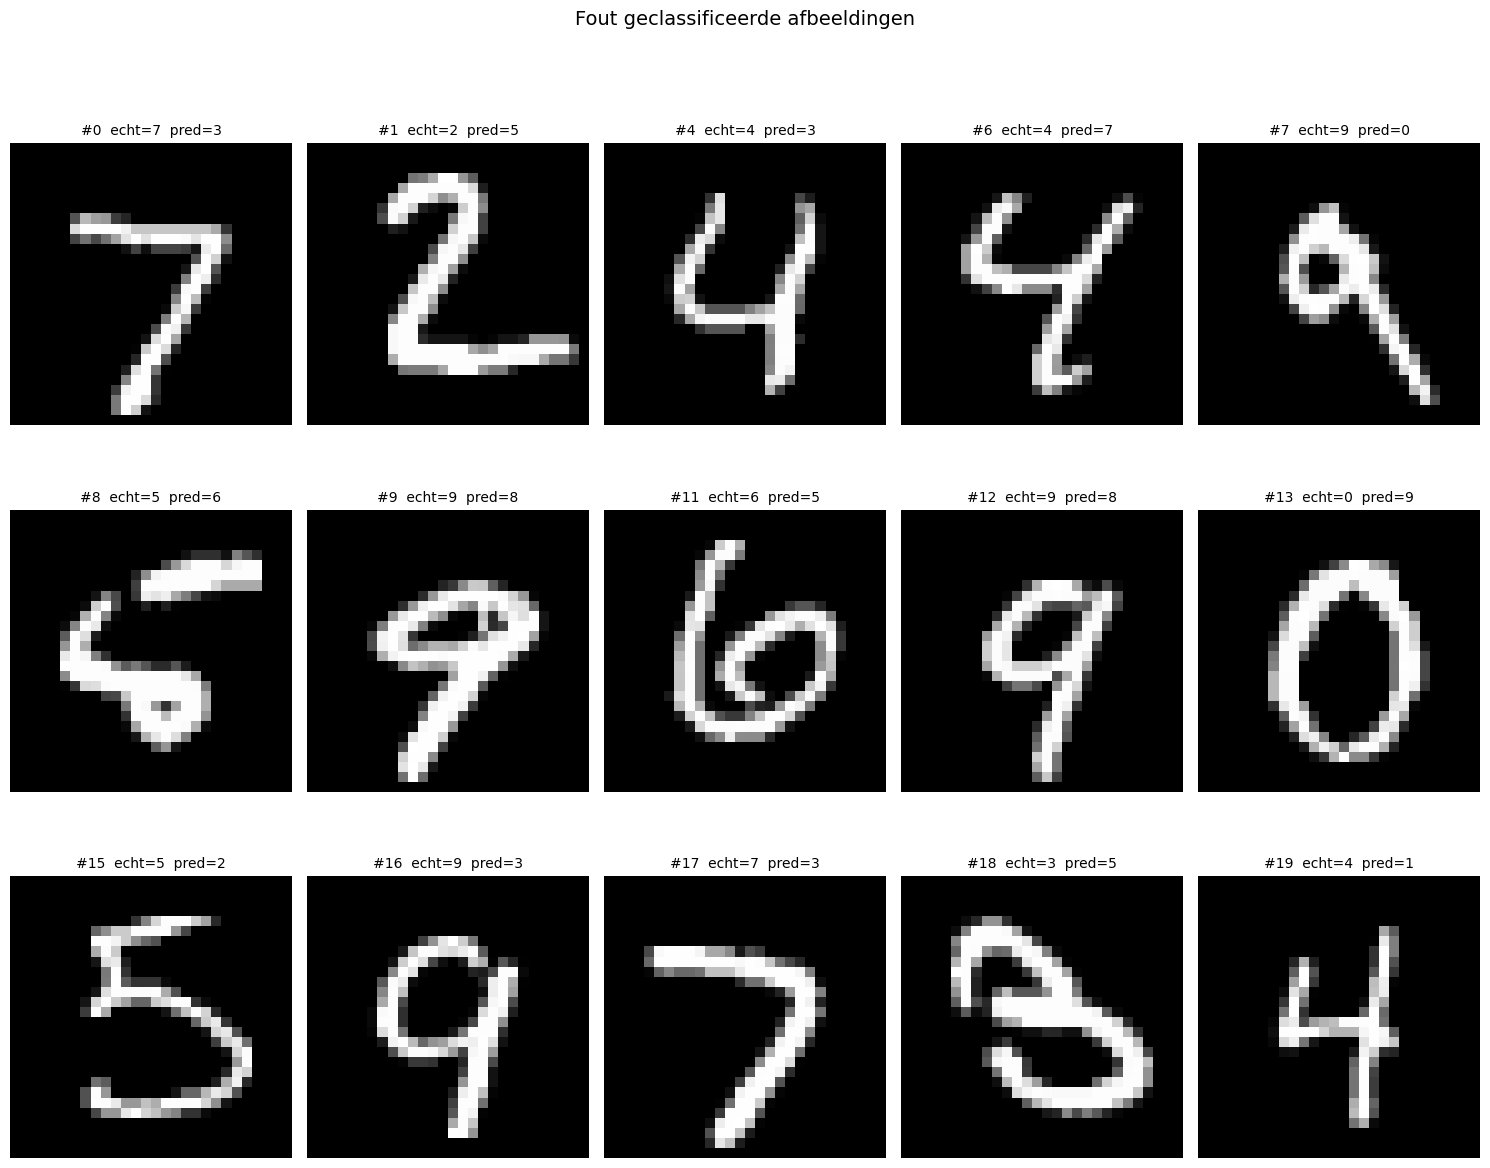


── Feature-waarden van foute voorspellingen ──

Afbeelding 0  |  echt=7  voorspeld=3
        procent_donker: 0.0906
       horiz_symmetrie: 0.1142
        vert_verdeling: 0.5493
       horiz_verdeling: 0.4225
            bbox_ratio: 1.2500
           pixel_stdev: 0.2587
          aantal_gaten: 0.0000

Afbeelding 1  |  echt=2  voorspeld=5
        procent_donker: 0.1467
       horiz_symmetrie: 0.1563
        vert_verdeling: 0.4435
       horiz_verdeling: 0.5304
            bbox_ratio: 1.1111
           pixel_stdev: 0.3211
          aantal_gaten: 0.0000

Afbeelding 4  |  echt=4  voorspeld=3
        procent_donker: 0.0969
       horiz_symmetrie: 0.1184
        vert_verdeling: 0.4211
       horiz_verdeling: 0.3816
            bbox_ratio: 1.4286
           pixel_stdev: 0.2624
          aantal_gaten: 0.0000

Afbeelding 6  |  echt=4  voorspeld=7
        procent_donker: 0.1148
       horiz_symmetrie: 0.1171
        vert_verdeling: 0.5889
       horiz_verdeling: 0.4222
            bbox_ratio: 1

In [15]:
fouten = []
for i in range(N_TEST):
    img  = X_test[i]
    feat = extract_features(img)
    pred = voorspel(boom, feat)
    echt = int(y_test[i])
    if pred != echt:
        fouten.append((i, img, feat, echt, pred))

if not fouten:
    print("Geen fouten gevonden!")
else:
    n = len(fouten)
    cols = min(n, 5)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 4 * rows))
    if n == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for ax_idx, (i, img, feat, echt, pred) in enumerate(fouten):
        axes[ax_idx].imshow(img, cmap='gray')
        axes[ax_idx].set_title(f"#{i}  echt={echt}  pred={pred}", fontsize=10)
        axes[ax_idx].axis('off')

    for ax_idx in range(len(fouten), len(axes)):
        axes[ax_idx].axis('off')

    fig.suptitle("Fout geclassificeerde afbeeldingen", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print("\n── Feature-waarden van foute voorspellingen ──\n")
    for i, _, feat, echt, pred in fouten:
        print(f"Afbeelding {i}  |  echt={echt}  voorspeld={pred}")
        for naam, waarde in zip(FEATURE_NAMEN, feat):
            print(f"  {naam:>20}: {waarde:.4f}")
        print()

### Bespreking (Deel 4)

**Wat valt op?**

- **Sterk onderscheidend:** `aantal_gaten` werkt uitstekend voor **0, 8** en grotendeels voor **4, 6, 9**. Cijfer **1** is bijna altijd correct dankzij de lage pixeldichtheid.
- **Zwak onderscheidend:** De drie-weg splitsing **2 / 3 / 5** is het kwetsbaarst. Alle drie hebben 0 gaten en vergelijkbare dichtheid; ze zijn moeilijk van elkaar te scheiden met alleen deze globale features.
- **Handschrift-variatie** is een grote uitdaging: een schuin geschreven **1** kan een hoge `horizontale_symmetrie` hebben en daardoor als **3** geclassificeerd worden.
- **Verbetermogelijkheden:** features die *lokale* gebieden beschrijven (bijv. kwadrant-dichtheden, Sobel-randen, diagonale projecties) zouden de 2/3/5-verwarring sterk verminderen.

### Deel 5: Runnen als embedded code

Zoals aan het begin van de cursus besproken gaat het project over handgeschreven nummers herekennen op een MysteryDevice met de volgende eigenschappen:

- Input scherm waarmee een nieuwe plaatje als ndarray aangemaakt kan worden door de gebruiker.
- Zeer beperkt RAM (256 KB)
- Beperkte opslag (1 MB voor programma + model)
- Geen GPU
- Embedded python

| Eigenschap | Waarde | Voldoet? |
|------------|--------|----------|
| 256 KB RAM | Zie analyse hieronder | check |
| 1 MB opslag | Zie analyse hieronder | check |
| Geen GPU | Alle berekeningen zijn CPU-loops | check |
| Embedded Python | Zie onderstaand | NO |

In [16]:
bytes_per_image     =  28 * 28 * 1
bytes_float_copy    =  28 * 28 * 4
bytes_flood_fill    =  28 * 28 * 1 * 3
bytes_feature_vec   =  7 * 8
bytes_tree_nodes    =  20 * 5 * 8

totaal = (bytes_per_image + bytes_float_copy +
          bytes_flood_fill + bytes_feature_vec + bytes_tree_nodes)

print("── Geheugen per inferentie (één afbeelding) ──")
print(f"  Input afbeelding (uint8)      : {bytes_per_image:>6} bytes")
print(f"  Float-kopie voor berekeningen : {bytes_float_copy:>6} bytes")
print(f"  Flood-fill hulparrays (3×)    : {bytes_flood_fill:>6} bytes")
print(f"  Feature vector (7 floats)     : {bytes_feature_vec:>6} bytes")
print(f"  Beslissingsboom (~20 knopen)  : {bytes_tree_nodes:>6} bytes")
print(f"  {'-' * 20}")
print(f"  Totaal algoritme-data         : {totaal:>6} bytes  ({totaal/1024:.1f} KB)")
print()
print(f"  Beschikbaar RAM               : {256*1024:>6} bytes  (256 KB)")
print()

if totaal < 256 * 1024:
    print(" Algoritme-DATA past ruim in 256 KB RAM.")
else:
    print(" Algoritme-data past NIET.")

print()
print("── Opslag ──")
print("  Beslissingsboom (hardgecodeerd, geen modelbestand): ~2 KB")
print("  Python-broncode                                   : ~20 KB")
print("  Totaal                                            : ~22 KB  << 1 MB")

print()
print("── Knelpunt: numpy ──")
print("  Standaard numpy-installatie: ~10–40 MB → PAST NIET in 256 KB RAM.")
print()
print("── Oplossingen ──")
print("  Optie A: ulab (micro-numpy voor MicroPython)")
print("           Ondersteunt array-bewerkingen, werkt op RP2040/ESP32.")
print("           Let op: niet alle numpy-functies beschikbaar (np.fliplr bijv.)")
print("           → kleine aanpassingen in de feature-code nodig.")
print()
print("  Optie B: pure Python loops (geen numpy)")
print("           Afbeelding inlezen als bytes-object (28×28 = 784 bytes).")
print("           Alle berekeningen met gewone for-loops en lijstbegrip.")
print("           → trager, maar 0 externe dependencies.")
print()
print("  Conclusie:")
print("  Het algoritme past qua LOGICA en DATA op het apparaat.")
print("  Standaard numpy past NIET. Met ulab of pure Python is het haalbaar.")

── Geheugen per inferentie (één afbeelding) ──
  Input afbeelding (uint8)      :    784 bytes
  Float-kopie voor berekeningen :   3136 bytes
  Flood-fill hulparrays (3×)    :   2352 bytes
  Feature vector (7 floats)     :     56 bytes
  Beslissingsboom (~20 knopen)  :    800 bytes
  --------------------
  Totaal algoritme-data         :   7128 bytes  (7.0 KB)

  Beschikbaar RAM               : 262144 bytes  (256 KB)

 Algoritme-DATA past ruim in 256 KB RAM.

── Opslag ──
  Beslissingsboom (hardgecodeerd, geen modelbestand): ~2 KB
  Python-broncode                                   : ~20 KB
  Totaal                                            : ~22 KB  << 1 MB

── Knelpunt: numpy ──
  Standaard numpy-installatie: ~10–40 MB → PAST NIET in 256 KB RAM.

── Oplossingen ──
  Optie A: ulab (micro-numpy voor MicroPython)
           Ondersteunt array-bewerkingen, werkt op RP2040/ESP32.
           Let op: niet alle numpy-functies beschikbaar (np.fliplr bijv.)
           → kleine aanpassingen in d